In [2]:
import arviz as az
import matplotlib.pyplot as plt

import numpy as np
from pyro.infer import MCMC, NUTS
import torch
from pyro.infer import Predictive
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
import pandas as pd
import pymc as pm
import pytensor

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

/home/ronshi/.conda/envs/pybandits/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Simulate Data

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [34]:
y_train.shape

torch.Size([30000, 1])

In [36]:
def create_data( n_samples):
    amount = np.random.uniform(0, 2,size=(n_samples))
    probs_obs = (amount**2)/4
    y_obs = np.random.binomial(1, probs_obs)
    x_obs = amount.reshape(-1, 1)
    x = torch.from_numpy(x_obs).float()
    y = torch.from_numpy(y_obs).float()

    return x, y, probs_obs



c_params = [ -4,2,3,3,1,-3 ]
n_bias_features = 0
n_features = 0
n_samples_train= 30000
n_samples_val= 2000
n_samples_test= 30000

# train
x_train, y_train, probs_obs_train = create_data(n_samples_train)
x_val, y_val, probs_obs_val = create_data(n_samples_train)
x_test, y_test, probs_obs_test = create_data(n_samples_test)

# test
# x_obs_test = np.random.uniform(0, 1, size=(n_users, num_features))
# probs_obs_test = sigmoid(c_params[0] + np.matmul(x_obs_test, c_params[1:]))
# y_obs_test = np.random.binomial(1, probs_obs_test)



In [37]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn

class Torch_BNN(nn.Module):
    def __init__(self, in_dim, out_dim=1, hid_dim=10):
        super().__init__()
        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = nn.Linear(in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = nn.Linear(hid_dim, out_dim)  # Hidden to output layer

    def forward(self, x_features, x_actions):
        x = torch.cat((x_features, x_actions))
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()
        return logits


class BNN(PyroModule):
    def __init__(self, in_dim=n_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = PyroModule[nn.Linear](in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = PyroModule[nn.Linear](hid_dim, out_dim)  # Hidden to output layer

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()

        # Sampling _model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

# variational inference

## Using Pyro's SVI

In [7]:
bnn_model = BNN(in_dim=n_features + 1)

In [8]:
next(bnn_model.named_children())

('activation', Tanh())

In [191]:
hid_dim = 10
in_dim = n_features + 1
out_dim = 1

for name, param in bnn_model.named_parameters():
        print(name)
        # Define the mean and standard deviation for each parameter
        mu = pyro.param(f"{name}_mu", torch.randn(param.shape))
        sigma = pyro.param(f"{name}_sigma", torch.ones(param.shape), constraint=dist.constraints.positive)

In [9]:
def train_bnn(bnn_model, x_train, y_train, n_epochs):
    pyro.clear_param_store()
    model_guide = AutoDiagonalNormal(bnn_model)
    optimizer = pyro.optim.Adam({"lr": 0.01})

    svi = SVI(bnn_model, model_guide, optimizer, loss=Trace_ELBO())
    pyro.clear_param_store()

    num_epochs = n_epochs
    progress_bar = trange(num_epochs)
    loss_list = []
    for epoch in progress_bar:
        loss = svi.step(x_train, y_train)

        # claculate preds for train/val data (ADD)
        loss_list.append(loss)
        progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

    return model_guide, loss_list


In [38]:
model_guide, loss_list = train_bnn(bnn_model, x_train, y_train, 1500)

100%|██████████| 1500/1500 [00:09<00:00, 153.68it/s, loss=0.420]


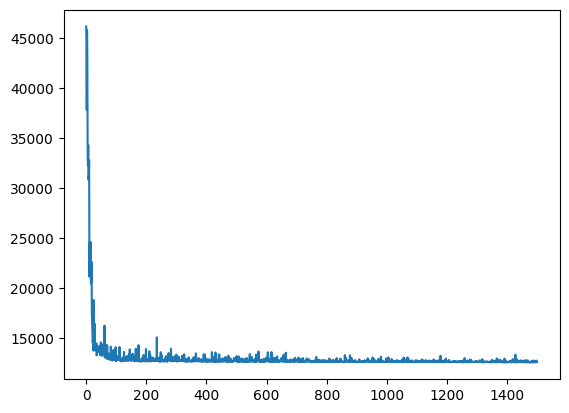

In [39]:
plt.figure()
plt.plot(loss_list)

In [237]:
bnn_model.__setattr__(layer1)

tensor([[  4.8584,  -3.0120,  -0.9643,  -4.1992,  -5.4243,   2.3484],
        [  6.7240,   0.3625,  -2.6595,   1.2809,   1.7067,  10.7603],
        [  7.7203,   6.2626,  -5.5176,  -0.5521,  -1.1782,   1.2175],
        [  9.3290,  -7.9461,   0.4565,  -1.7000,  -1.2506,   2.2413],
        [ -3.6714,  -1.3416,   8.9496,  -1.6657,   1.6880,   1.0346],
        [  7.6085,   3.4642,  -1.9090, -10.7311,   3.2813,  -2.2378],
        [  1.0816,  -8.8744,   7.2694,   1.5165,   0.0729,   8.6175],
        [  5.4953,   2.2616,   3.8114,   3.4282,   7.4860,   6.4161],
        [ -0.6802,  -6.5099,  -6.6501,  -1.4413,   3.8185,   0.7643],
        [  4.5011,   8.0377,  -1.4946,  -6.2176,  -4.8324,   4.6898]])

In [279]:
PyroSample(dist.Normal(0., 1).expand([hid_dim, in_dim]).to_event(2))

PyroSample(prior=Independent(Normal(loc: torch.Size([10, 6]), scale: torch.Size([10, 6])), 2))

In [280]:
 PyroSample(dist.Normal(0., 1).expand([hid_dim]).to_event(1))

PyroSample(prior=Independent(Normal(loc: torch.Size([10]), scale: torch.Size([10])), 1))

In [281]:

PyroSample(dist.Normal(0., 1).expand([out_dim, hid_dim]).to_event(2))

PyroSample(prior=Independent(Normal(loc: torch.Size([1, 10]), scale: torch.Size([1, 10])), 2))

In [282]:

PyroSample(dist.Normal(0., 1).expand([out_dim]).to_event(1))

PyroSample(prior=Independent(Normal(loc: tensor([0.]), scale: tensor([1.])), 1))

In [251]:
getattr(getattr(bnn_model, curr_module),curr_param)

tensor([[100000.1641,  99999.9453, 100000.0000,  99999.9922, 100000.0156,
          99999.8516],
        [100000.1406, 100000.1406,  99999.9609,  99999.8984, 100000.1875,
         100000.1328],
        [ 99999.8984,  99999.9844,  99999.8984,  99999.8828,  99999.8438,
          99999.9922],
        [100000.0703, 100000.1797,  99999.8750, 100000.1250, 100000.0234,
         100000.0938],
        [100000.1172, 100000.0156, 100000.0938,  99999.9531,  99999.9531,
         100000.1406],
        [ 99999.8594, 100000.0000, 100000.0938, 100000.1328, 100000.0000,
          99999.9609],
        [ 99999.8438,  99999.9219, 100000.0781, 100000.0547,  99999.8984,
          99999.9531],
        [100000.0078,  99999.9062, 100000.0469, 100000.0312, 100000.1328,
          99999.9844],
        [100000.0391,  99999.9609,  99999.8828,  99999.9922,  99999.9453,
          99999.9141],
        [ 99999.9453,  99999.8438, 100000.0000,  99999.9844,  99999.8828,
         100000.0547]])

In [265]:
n_features

5

In [249]:
setattr(getattr(bnn_model, curr_module),curr_param,  PyroSample(dist.Normal(100000., 0.1).expand([hid_dim, in_dim]).to_event(2)))

In [256]:
curr_std = mean_field_guide.get_posterior(param).base_dist.scale
curr_std.std

<function Tensor.std>

In [273]:
print(param)
mean_field_guide.get_posterior(param).base_dist.loc

layer1.weight


Parameter containing:
tensor([-1.8390, -0.2211,  2.3922, -1.2430,  2.1501,  5.1411, -1.3130, -0.0082,
        -1.0409,  3.2473, -1.3016,  1.4725,  0.5382, -1.1291,  0.3665, -0.4808,
        -2.4154,  0.4335, -2.0051,  2.5338, -1.6094, -2.0527,  0.0671,  1.3241,
        -0.6471,  0.5738,  0.3295, -1.3543,  0.6807,  1.4233, -2.6267, -0.4531,
        -3.0715,  0.5051, -1.4007, -1.2289,  1.0228,  0.0458, -1.8842, -1.8284,
         2.0138,  0.8658,  1.9456, -1.1918, -2.1644, -1.4984,  0.8883, -0.2330,
         0.8915, -1.0408,  0.1105, -1.7822, -0.2625,  0.3437,  2.0774,  0.6083,
        -0.4427,  0.5086, -0.1423, -0.8446,  0.9841,  2.9540,  0.3472,  3.1866,
         0.2044,  0.5243, -1.4609,  2.0739,  0.3746, -1.0792, -0.7619, -1.7987,
         0.5577, -0.1742,  1.7312, -0.7479, -0.9130, -1.2885, -1.8150, -0.6247,
        -1.1200], requires_grad=True)

In [258]:
PyroSample(dist.Normal(100000., 0.1).expand([hid_dim, in_dim]).to_event(2))

PyroSample(prior=Independent(Normal(loc: torch.Size([10, 6]), scale: torch.Size([10, 6])), 2))

In [275]:
for param in mean_field_guide._unconstrained_shapes.keys():
    print("========================")
    print("========================")
    print(param)
    curr_mean = mean_field_guide.get_posterior(param).base_dist.loc
    curr_std = mean_field_guide.get_posterior(param).base_dist.scale
    curr_module = param.split('.')[0]
    curr_param = param.split('.')[1]
    print(mean_field_guide.get_posterior(param).base_dist.loc)
    print("========================")
    print(mean_field_guide.get_posterior(param).base_dist.scale)
    print("========================")

    # setattr(getattr(bnn_model, curr_module),curr_param,  PyroSample(dist.Normal(100000., 0.1).expand([hid_dim, in_dim]).to_event(2)))


# mean_field_guide.get_posterior('layer1.weight').base_dist.loc
# mean_field_guide.get_posterior('layer1.weight').base_dist.scale

layer1.weight
Parameter containing:
tensor([-1.8390, -0.2211,  2.3922, -1.2430,  2.1501,  5.1411, -1.3130, -0.0082,
        -1.0409,  3.2473, -1.3016,  1.4725,  0.5382, -1.1291,  0.3665, -0.4808,
        -2.4154,  0.4335, -2.0051,  2.5338, -1.6094, -2.0527,  0.0671,  1.3241,
        -0.6471,  0.5738,  0.3295, -1.3543,  0.6807,  1.4233, -2.6267, -0.4531,
        -3.0715,  0.5051, -1.4007, -1.2289,  1.0228,  0.0458, -1.8842, -1.8284,
         2.0138,  0.8658,  1.9456, -1.1918, -2.1644, -1.4984,  0.8883, -0.2330,
         0.8915, -1.0408,  0.1105, -1.7822, -0.2625,  0.3437,  2.0774,  0.6083,
        -0.4427,  0.5086, -0.1423, -0.8446,  0.9841,  2.9540,  0.3472,  3.1866,
         0.2044,  0.5243, -1.4609,  2.0739,  0.3746, -1.0792, -0.7619, -1.7987,
         0.5577, -0.1742,  1.7312, -0.7479, -0.9130, -1.2885, -1.8150, -0.6247,
        -1.1200], requires_grad=True)
tensor([0.1345, 0.1644, 0.1723, 0.1296, 0.1357, 0.1766, 0.1942, 0.2325, 0.4468,
        0.6532, 0.3292, 0.1771, 0.0868, 0.0647

In [286]:
pyro.__dict__


{'__name__': 'pyro',
 '__doc__': None,
 '__package__': 'pyro',
 '__loader__': <_frozen_importlib_external.SourceFileLoader at 0x7f66f9ca2f10>,
 '__spec__': ModuleSpec(name='pyro', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f66f9ca2f10>, origin='/home/ronshi/.conda/envs/pybandits/lib/python3.9/site-packages/pyro/__init__.py', submodule_search_locations=['/home/ronshi/.conda/envs/pybandits/lib/python3.9/site-packages/pyro']),
 '__path__': ['/home/ronshi/.conda/envs/pybandits/lib/python3.9/site-packages/pyro'],
 '__file__': '/home/ronshi/.conda/envs/pybandits/lib/python3.9/site-packages/pyro/__init__.py',
 '__cached__': '/home/ronshi/.conda/envs/pybandits/lib/python3.9/site-packages/pyro/__pycache__/__init__.cpython-39.pyc',
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.",
  '__package__': '',
  '__loader__': _frozen_importlib.Buil

In [42]:

pyro.clear_param_store()

#_model = BNN(hid_dim=10, n_hid_layers=5, prior_scale=5.)
deep_model = BNN(in_dim=n_features + 1)
mean_field_guide = AutoDiagonalNormal(deep_model)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(deep_model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 1500
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)

    # claculate preds for train/val data (ADD)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

100%|██████████| 1500/1500 [00:08<00:00, 179.54it/s, loss=0.419]


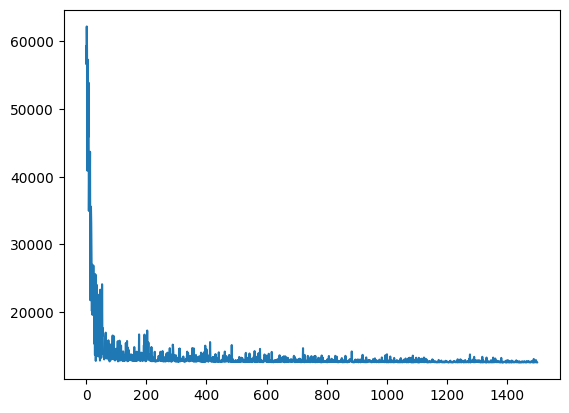

In [43]:
plt.figure()
plt.plot(loss_list)

## check parameters and logits

In [57]:
type(deep_model._modules)


dict

In [56]:
for name, attr in deep_model._modules:
    print(name, attr)

_pyro_name 
_pyro_context <pyro.nn.module._Context object at 0x7f66c4c11b80>
_pyro_params OrderedDict()
_pyro_samples OrderedDict()
training True
_parameters {}
_buffers {}
_non_persistent_buffers_set set()
_backward_pre_hooks OrderedDict()
_backward_hooks OrderedDict()
_is_full_backward_hook None
_forward_hooks OrderedDict()
_forward_hooks_with_kwargs OrderedDict()
_forward_hooks_always_called OrderedDict()
_forward_pre_hooks OrderedDict()
_forward_pre_hooks_with_kwargs OrderedDict()
_state_dict_hooks OrderedDict()
_state_dict_pre_hooks OrderedDict()
_load_state_dict_pre_hooks OrderedDict()
_load_state_dict_post_hooks OrderedDict()
_modules {'activation': Tanh(), 'layer1': PyroLinear(in_features=6, out_features=10, bias=True), 'layer2': PyroLinear(in_features=10, out_features=1, bias=True)}


In [44]:
predictive = Predictive(deep_model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight", "layer1.bias", "obs", "_RETURN"))
samples = predictive(x_train)
logits = samples['_RETURN'].squeeze()

0.10534815408849002
tensor(0.0962)
0.01149369218569655
tensor(0.0129)
0.014382232769857627
tensor(0.0153)
5.1097908330477615e-05
tensor(0.0034)
0.05754593169048015
tensor(0.0547)


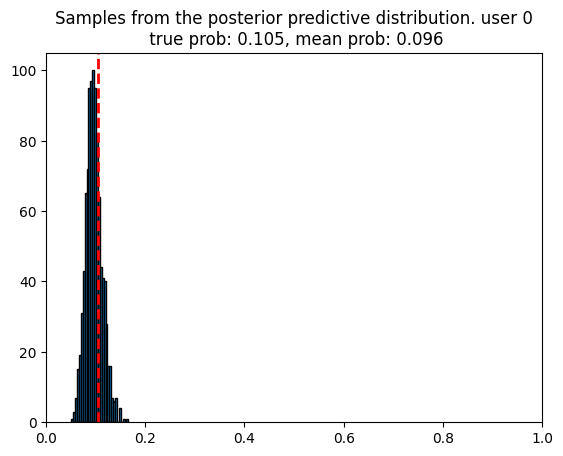

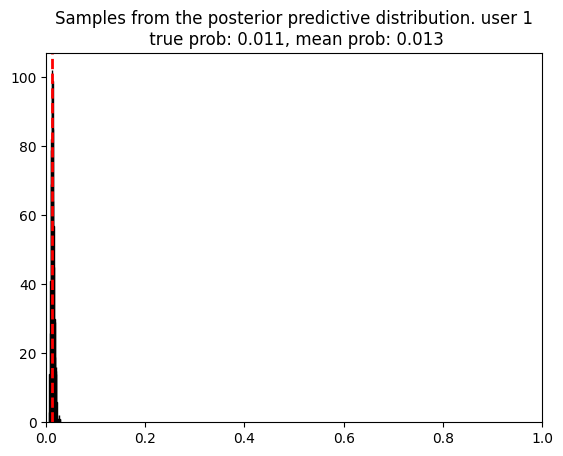

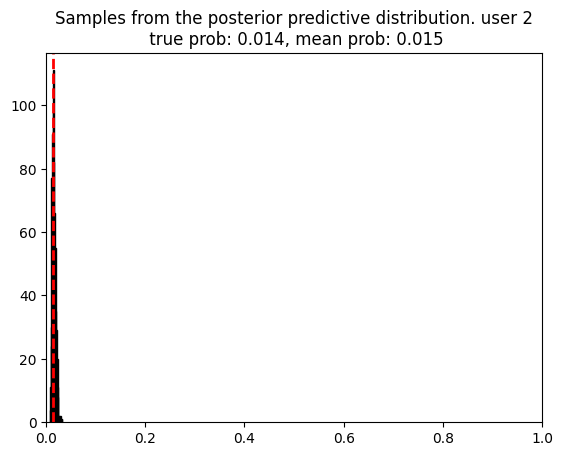

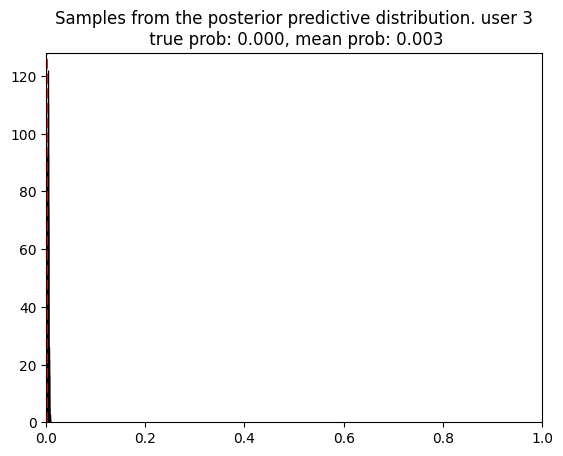

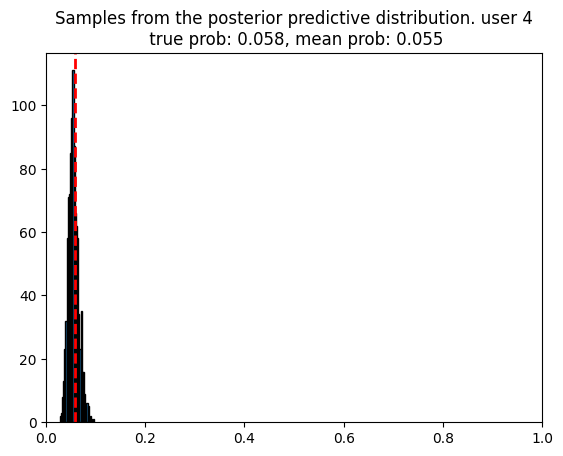

In [45]:
for ind in range(5):
    curr_pred = probs_obs_train[ind]

    preds_from_model = sigmoid(logits[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


## check test data

In [46]:

samples_test = predictive(x_test)
logits_test = samples_test['_RETURN'].squeeze()


0.3026007027241604
tensor(0.2852)
0.18286817841474967
tensor(0.1638)
0.004980535086006289
tensor(0.0079)
0.0076749104111835794
tensor(0.0099)
0.0994799647912046
tensor(0.0906)
0.0020041301281502224
tensor(0.0056)
0.24344420524212945
tensor(0.2226)
0.15437495192517128
tensor(0.1380)
0.016722003676297358
tensor(0.0172)
0.7303888714702389
tensor(0.7360)


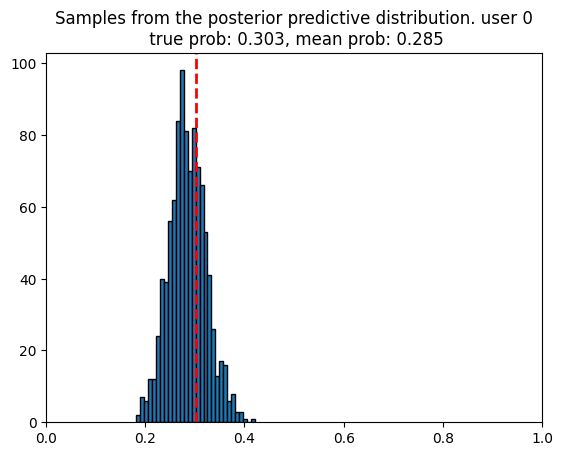

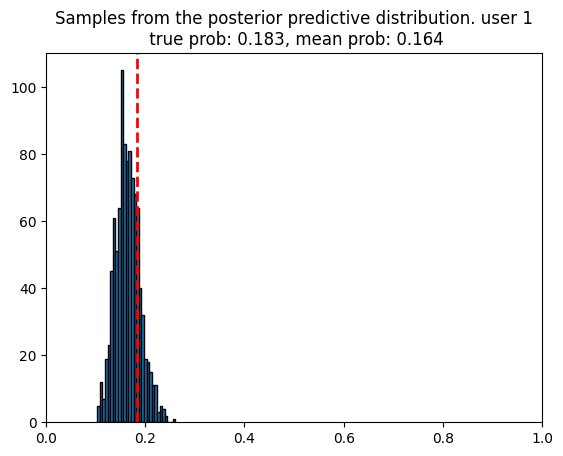

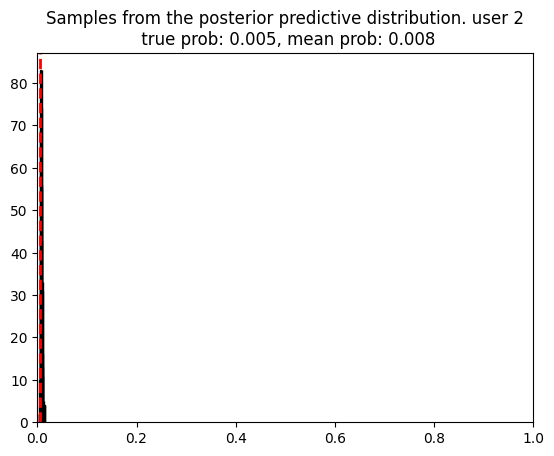

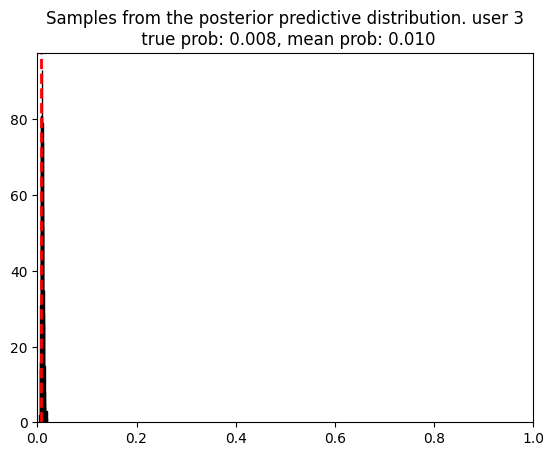

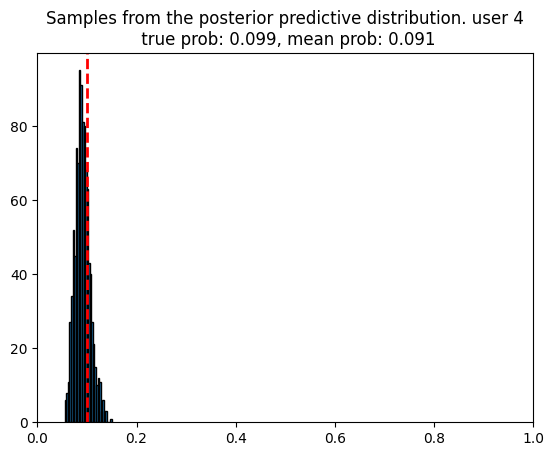

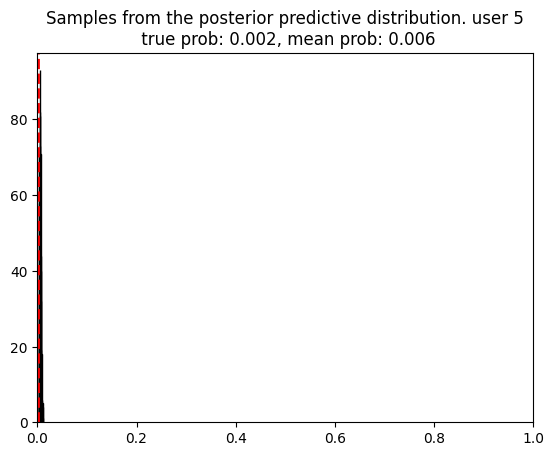

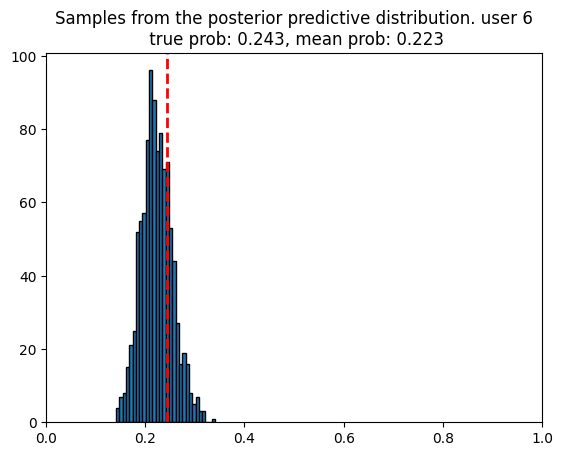

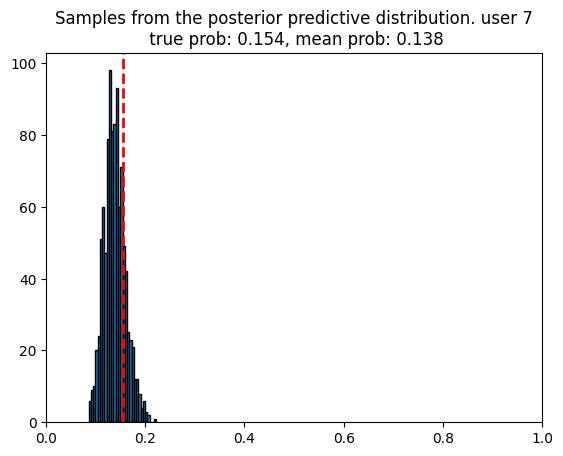

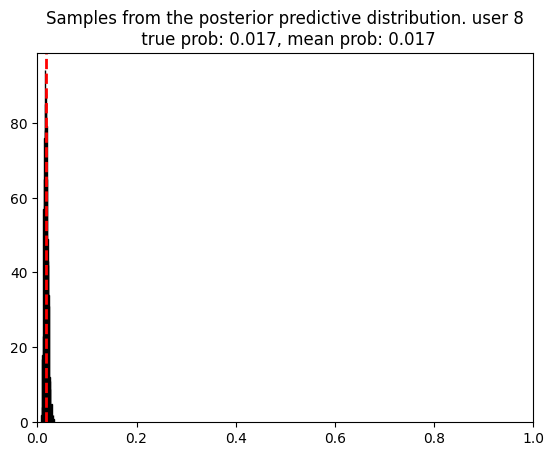

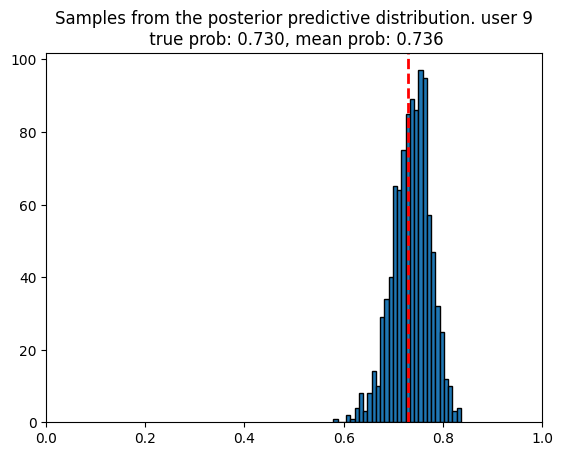

In [47]:
for ind in range(10):
    curr_pred = probs_obs_test[ind]

    preds_from_model = sigmoid(logits_test[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


In [30]:
### Given a trained _model - find optimal quantity

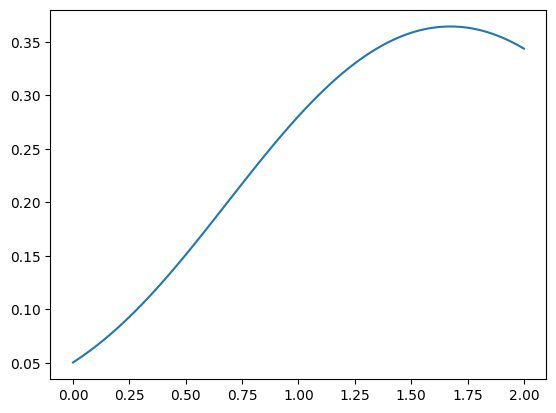

In [152]:
# first user:

ind = 3
xx = x_test[ind,:-1]
amount = np.linspace(0, 2, 100)
logit_bias = c_params[-1] + np.matmul(xx[0:n_bias_features], c_params[0:n_bias_features])

logit_quant = c_params[n_bias_features]*xx[n_bias_features] *amount -  c_params[n_bias_features+1]*xx[n_bias_features+1]* amount ** 2
probs = sigmoid(logit_bias + logit_quant)
probs
plt.figure()
plt.plot(amount, probs)


In [126]:
# regular pytorch nn:
torch_model = Torch_BNN(in_dim=n_features + 1)
#

In [127]:
# read named parameters from torch_model
model_param_names= []
for name, param in torch_model.named_parameters():
    model_param_names.append(name)



In [128]:
model_param_names


['layer1.weight', 'layer1.bias', 'layer2.weight', 'layer2.bias']

In [129]:
# just get a sample of the _model parameters
predictive = Predictive(deep_model, guide=mean_field_guide, num_samples=1,
                        return_sites= tuple(model_param_names) + ("obs", "_RETURN"))
dummy_sample = predictive(torch.zeros(1, n_features + 1))

In [130]:
# Load sampled parameters to torch_model and freeze them
for name, param in torch_model.named_parameters():
    param.data = dummy_sample[name].squeeze()
    param.requires_grad_(False)
    print(f"Parameter name: {name}")


Parameter name: layer1.weight
Parameter name: layer1.bias
Parameter name: layer2.weight
Parameter name: layer2.bias


In [153]:
# find optimal parameter
# Example input tensor
x_actions = torch.tensor([1.0], requires_grad=True)

# Define the optimizer
optimizer = torch.optim.SGD([x_actions], lr=0.01)

# Optimization loop
for kk in range(100):
    print(f"{kk}. Maximized output: {torch_model(xx, x_actions)}. Optimized input: {x_actions}")# Number of iterations can be adjusted
    optimizer.zero_grad()
    output = torch_model(xx, x_actions)
    loss = -output
    loss.backward()
    optimizer.step()



0. Maximized output: -1.1343663930892944. Optimized input: tensor([1.], requires_grad=True)
1. Maximized output: -1.1016513109207153. Optimized input: tensor([1.0182], requires_grad=True)
2. Maximized output: -1.0709940195083618. Optimized input: tensor([1.0359], requires_grad=True)
3. Maximized output: -1.0423492193222046. Optimized input: tensor([1.0530], requires_grad=True)
4. Maximized output: -1.0156503915786743. Optimized input: tensor([1.0694], requires_grad=True)
5. Maximized output: -0.9908155202865601. Optimized input: tensor([1.0853], requires_grad=True)
6. Maximized output: -0.9677509069442749. Optimized input: tensor([1.1007], requires_grad=True)
7. Maximized output: -0.9463571310043335. Optimized input: tensor([1.1154], requires_grad=True)
8. Maximized output: -0.926531195640564. Optimized input: tensor([1.1297], requires_grad=True)
9. Maximized output: -0.9081698656082153. Optimized input: tensor([1.1433], requires_grad=True)
10. Maximized output: -0.8911713361740112. Op

## Simple BNN

In [66]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn


class Simple_BNN(PyroModule):
    def __init__(self, in_dim=num_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.layer1 = PyroModule[nn.Linear](in_dim, out_dim)

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, in_dim, ]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))


    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        logits = self.layer1(x).squeeze()

        # Sampling _model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

In [68]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store()

#_model = BNN(hid_dim=10, n_hid_layers=5, prior_scale=5.)
model = Simple_BNN(in_dim=num_features)
mean_field_guide = AutoDiagonalNormal(model)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 10000
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

100%|██████████| 10000/10000 [01:26<00:00, 116.12it/s, loss=0.375]


## check parameters

In [81]:
predictive = Predictive(model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight","layer1.bias",  "obs", "_RETURN"))
samples = predictive(x_train)

In [85]:
samples['layer1.weight'].squeeze()

tensor([[-5.1278,  2.0692,  2.7831],
        [-4.9906,  2.1065,  2.7627],
        [-4.9230,  2.0463,  2.7396],
        ...,
        [-5.0156,  2.1743,  2.7812],
        [-5.0338,  2.0542,  2.8160],
        [-5.0444,  2.0242,  2.7726]])

In [78]:
mean_field_guide.get_posterior().mean

Parameter containing:
tensor([-5.0106,  2.0551,  2.7915, -1.8419], requires_grad=True)

In [79]:
mean_field_guide.get_posterior().stddev

tensor([0.0657, 0.0463, 0.0439, 0.0283], grad_fn=<SqrtBackward0>)

In [ ]:
for name, param in model.named_parameters():
    print(f"Parameter name: {name}")
    print(param)